# ** PROJECT 2 **

## Day 1 & 2 (Week 5) - Data Cleaning & EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

df_final_demo = pd.read_csv("df_final_demo.txt")
df_final_experiment_clients = pd.read_csv("df_final_experiment_clients.txt")
df_final_web_data_pt_1 = pd.read_csv("df_final_web_data_pt_1.txt")
df_final_web_data_pt_2 = pd.read_csv("df_final_web_data_pt_2.txt")

In [2]:
VANGUARD_RED = "#96151D"
DARK_GRAY    = "#3A3A3C"
brand_colors = [DARK_GRAY, VANGUARD_RED]   # Control, Test

In [3]:
df_final_demo.shape

(70609, 9)

In [4]:
df_final_demo.info()

<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  str    
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 4.9 MB


In [5]:
df_final_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [6]:
df_final_demo.tail()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0
70608,5602139,21.0,254.0,59.5,F,3.0,157498.73,7.0,7.0


In [7]:
for col in df_final_demo.columns:
    print(col)
    print(df_final_demo[col].unique())
    print()

client_id
[ 836976 2304905 1439522 ...  333913 1573142 5602139]

clnt_tenure_yr
[ 6.  7.  5. 16. 12. 30. 15.  8.  4.  3. 10. 11. 13. 14. 19. 18. 25. 23.
 21. 17.  9. 27. 24. 20. 28. 22. 29. 46. 26. 32. 33. 35.  2. 38. 31. 48.
 34. 36. 51. nan 47. 49. 37. 39. 40. 55. 42. 44. 43. 50. 54. 41. 45. 52.
 62.]

clnt_tenure_mnth
[ 73.  94.  64. 198. 145.  71.  66. 361. 369. 189. 100.  99.  67. 193.
  58.  47. 122. 136. 101. 103.  70. 152. 160.  80.  88.  86.  65.  68.
  93.  85. 168. 142. 228. 223. 305. 286. 285. 280. 254. 253. 278. 221.
 216. 212. 204. 260. 116. 130. 177. 159. 190.  89.  91. 129. 329.  92.
  82. 169. 239.  69. 178.  95.  63. 187. 288. 261. 251. 250.  56.  60.
 123. 175. 188.  59. 336. 149. 156. 330. 155. 167.  96. 242. 163.  81.
 182. 134. 113. 172. 120. 105. 271. 244. 200. 157.  78. 151. 121. 184.
 335. 357. 111. 185.  76. 148.  97.  83. 347. 324. 162. 194.  74. 186.
 300. 289. 295. 282. 270. 246. 229. 206. 109. 343. 176. 144. 161. 179.
 106. 154. 119.  75. 166. 143. 202. 32

In [8]:
df_final_demo["gendr"].value_counts()

gendr
U    24122
M    23724
F    22746
X        3
Name: count, dtype: int64

In [9]:
df_final_demo["gendr"] = df_final_demo["gendr"].replace("X", "U")

In [10]:
df_final_demo["gendr"].value_counts(dropna=False)

gendr
U      24125
M      23724
F      22746
NaN       14
Name: count, dtype: int64

In [11]:
df_final_demo["num_accts"].value_counts()

num_accts
2.0    55497
3.0    12529
4.0     2241
5.0      284
6.0       33
7.0        8
1.0        2
8.0        1
Name: count, dtype: int64

In [12]:
df_final_demo["num_accts"].isnull().sum()

np.int64(14)

In [13]:
df_final_demo["bal"].value_counts()

bal
31188.62      5
29388.51      4
31398.74      3
24953.79      3
29389.11      3
             ..
1411062.68    1
101867.07     1
40745.00      1
475114.69     1
157498.73     1
Name: count, Length: 70333, dtype: int64

In [14]:
df_final_demo["bal"].isnull().sum()

np.int64(14)

In [15]:
df_final_demo["calls_6_mnth"].value_counts()

calls_6_mnth
6.0    14112
1.0    11016
2.0    10252
3.0     8752
0.0     7732
4.0     7175
5.0     6627
7.0     4929
Name: count, dtype: int64

In [16]:
df_final_demo["calls_6_mnth"].isnull().sum()

np.int64(14)

In [17]:
df_final_demo["logons_6_mnth"].value_counts()

logons_6_mnth
9.0    12350
3.0    10243
4.0    10220
7.0     9893
5.0     9254
6.0     7878
8.0     4810
2.0     3009
1.0     2938
Name: count, dtype: int64

In [18]:
df_final_demo["logons_6_mnth"].isnull().sum()

np.int64(14)

In [19]:
missing_df_final_demo = df_final_demo.isnull().sum()
missing_df_final_demo = missing_df_final_demo[missing_df_final_demo > 0].sort_values(ascending=False)
missing_df_final_demo

clnt_age            15
clnt_tenure_yr      14
clnt_tenure_mnth    14
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [20]:
categorical_df_final_demo = df_final_demo.select_dtypes(include="object").columns
numeric_df_final_demo = df_final_demo.select_dtypes(include="number").columns

print(categorical_df_final_demo)
print(numeric_df_final_demo)

Index(['gendr'], dtype='str')
Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth'],
      dtype='str')


/var/folders/zn/l77206j15c75_v0p6m45__wr0000gn/T/ipykernel_25030/415126083.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_df_final_demo = df_final_demo.select_dtypes(include="object").columns


We are creating a dictionary called dfs that gets together all 4 datasets in order to better understand each one of them and to clean all of them together.

In [21]:
dfs = {
    "demo": df_final_demo,
    "experiment": df_final_experiment_clients,
    "web_1": df_final_web_data_pt_1,
    "web_2": df_final_web_data_pt_2
}

for name, df in dfs.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Duplicates:", df.duplicated().sum())
    print("Nulls:")
    print(df.isnull().sum())
    print("Columns:", df.columns.tolist())


demo
Shape: (70609, 9)
Duplicates: 0
Nulls:
client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64
Columns: ['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth']

experiment
Shape: (70609, 2)
Duplicates: 0
Nulls:
client_id        0
Variation    20109
dtype: int64
Columns: ['client_id', 'Variation']

web_1
Shape: (343141, 5)
Duplicates: 2095
Nulls:
client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64
Columns: ['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']

web_2
Shape: (412264, 5)
Duplicates: 8669
Nulls:
client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64
Columns: ['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']


We here will clean all the column names.

In [22]:
for df in dfs.values():
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

As there are 14 null values in all columns (except for client_Age that has 15), that we will drop, since they do not have any important information. We will leave the row 9583.

In [23]:
df_final_demo[df_final_demo.isnull().any(axis=1)]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df_final_demo = df_final_demo.dropna(
    subset=[
        "clnt_tenure_yr",
        "clnt_tenure_mnth",
        "clnt_age",
        "gendr",
        "num_accts",
        "bal",
        "calls_6_mnth",
        "logons_6_mnth"
    ],
    how="all"
)

In [25]:
df_final_demo.isnull().sum()

client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            1
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
dtype: int64

Once we have cleaned the null values from df_final_demo, we will continue with the 2: experiment. Here we can see we have 20109 nulls in variation, but we will not drop them yet, since the number is quite high and we may need them.

In [26]:
df_final_experiment_clients["variation"].value_counts(dropna=False)

variation
Test       26968
Control    23532
NaN        20109
Name: count, dtype: int64

Next, web_1, we have 2095 duplicates, we need to look into them.

In [27]:
df_final_web_data_pt_1[df_final_web_data_pt_1.duplicated()]

,client_id,visitor_id,visit_id,process_step,date_time
365,9358626,148475529_63668223960,223297395_36250329195_832161,start,2017-04-28 12:27:28
368,5376894,622509328_44408201172,688984457_43441834354_912755,start,2017-04-28 14:20:01
383,438567,923318467_50708963627,330543236_29863358529_771432,start,2017-04-28 02:52:29
785,1423857,716830992_81930238382,568819166_80596727019_75889,confirm,2017-04-10 22:44:58
1816,372523,730241475_25771921122,25331354_74479847014_854987,start,2017-04-27 10:51:26
...,...,...,...,...,...
342621,1853345,831456815_77348510380,596026060_87178689141_910423,step_3,2017-04-13 19:39:24
342677,1251269,791822615_78146852845,763845944_55757914723_70888,start,2017-04-28 10:20:33
342679,1251269,791822615_78146852845,763845944_55757914723_70888,start,2017-04-28 10:18:20
342685,8350388,304440669_31040182888,143359398_96671536668_299057,start,2017-04-28 12:44:21


In [28]:
df_final_web_data_pt_1.drop_duplicates(inplace=True)

In [29]:
df_final_web_data_pt_1.duplicated().sum()

np.int64(0)

In [30]:
df_final_web_data_pt_1.shape

(341046, 5)

We have gone down from 343141 to 341046, exactly the 2095 repeated rows.

Now, web_2, same issue, 8669 duplicated rows. We will now check whether they are exact duplicated rows and will drop them as in web_1. So we will go down from 412264 rows to 403595 rows.


In [31]:
df_final_web_data_pt_2[df_final_web_data_pt_2.duplicated()]

,client_id,visitor_id,visit_id,process_step,date_time
125,3751049,937925261_74821699083,628817270_45049432060_475841,start,2017-05-15 23:09:44
143,9912156,746623513_52101087617,780044921_57678038107_984942,start,2017-05-03 14:09:52
326,5786602,893139880_61416949586,747153834_69434320996_858907,start,2017-05-10 01:49:09
328,5786602,893139880_61416949586,747153834_69434320996_858907,start,2017-05-10 01:48:45
375,5786602,893139880_61416949586,119968876_5423296886_390511,start,2017-06-08 02:14:09
...,...,...,...,...,...
412120,1672289,658797407_91003097342,430110748_90347503221_597628,start,2017-05-01 19:28:53
412163,4408245,14058946_73585431797,994148957_84373994761_991865,start,2017-06-06 09:17:23
412165,4408245,14058946_73585431797,994148957_84373994761_991865,start,2017-06-06 09:09:44
412167,4408245,14058946_73585431797,994148957_84373994761_991865,start,2017-06-06 08:51:16


In [32]:
df_final_web_data_pt_2.drop_duplicates(inplace=True)

In [33]:
df_final_web_data_pt_2.duplicated().sum()

np.int64(0)

In [34]:
df_final_web_data_pt_2.shape

(403595, 5)

Now we have cleaned all the data in the columns (nulls, duplicates, column names) we need to merge the 4 datasets. First, we will check the common column in all of them, which is client_id, and we need to see whether it is unique for all the datasets.

In [35]:
df_final_demo["client_id"].duplicated().sum()

np.int64(0)

In [36]:
df_final_experiment_clients["client_id"].duplicated().sum()

np.int64(0)

In [37]:
df_final_web_data_pt_1["client_id"].duplicated().sum()

np.int64(282655)

In [38]:
df_final_web_data_pt_2["client_id"].duplicated().sum()

np.int64(336165)

We can see that it is unique for df_final_demo and df_final_experiment_clients, which is what we need. It is not unique for the last two because 1 client can have many visits. This will indicate what kind of merge we need to do to each one of them. So, we will concat the last 2, since we have the same columns and the second one is just a follow up of the first one.

In [39]:
df_web = pd.concat([df_final_web_data_pt_1, df_final_web_data_pt_2], ignore_index=True)

We will now merge demo and experiment using client_id, since we do not have the same columns but we do have one common value, the client_id. We will merge it using the left merge because we need to keep all the rows in the first df, since we may have a client that it is not present in the experiment but we still want to keep this data.
We use the one-to-one validation to make sure there each client_id only shows up once in each df, so no duplicates for the same client_id

In [40]:
df_clients = df_final_demo.merge(df_final_experiment_clients, on="client_id", how="left", validate="one_to_one")

In the end we decided to drop the null values from the Variation column, because we are going to focus the analysis on only the experiment groups (Control and Test).

In [41]:
df_clients = df_clients.dropna(subset=["variation"])

Now we will merge our 2 new dfs by merging them using client_id as the same value, using df_web as left merge because we need to keep all of the actions taken by each client. If we do not have the personal information of a client, the info in these columns will appear as NaN, but it is ok as long as the action itself si kept. We will create a row for each movement and will add the client's personal info to each of the rows. Many to one due to this reason, one client_id may show up many times in df_web but only one in df_clients, otherwise an error will raise.

Here we are adding the personal information from each client to the specific actions they are doing in the web.

In [42]:
df_final = df_web.merge(df_clients, on="client_id", how="inner", validate="many_to_one")

In [43]:
df_final.shape

(317135, 14)

In [44]:
df_final["variation"].isna().sum()

np.int64(0)

In [45]:
df_final["variation"].value_counts(dropna=False)

variation
Test       176641
Control    140494
Name: count, dtype: int64

In [46]:
df_final["client_id"].isin(df_clients["client_id"]).all()

np.True_

In [47]:
df_final["client_id"].nunique()

50488

In [48]:
df_clients["client_id"].nunique()

50488

In [49]:
df_final.head()

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test


In [50]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 317135 entries, 0 to 317134
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   client_id         317135 non-null  int64  
 1   visitor_id        317135 non-null  str    
 2   visit_id          317135 non-null  str    
 3   process_step      317135 non-null  str    
 4   date_time         317135 non-null  str    
 5   clnt_tenure_yr    317135 non-null  float64
 6   clnt_tenure_mnth  317135 non-null  float64
 7   clnt_age          317123 non-null  float64
 8   gendr             317135 non-null  str    
 9   num_accts         317135 non-null  float64
 10  bal               317135 non-null  float64
 11  calls_6_mnth      317135 non-null  float64
 12  logons_6_mnth     317135 non-null  float64
 13  variation         317135 non-null  str    
dtypes: float64(7), int64(1), str(6)
memory usage: 58.2 MB


In [51]:
df_final.isnull().sum()

client_id            0
visitor_id           0
visit_id             0
process_step         0
date_time            0
clnt_tenure_yr       0
clnt_tenure_mnth     0
clnt_age            12
gendr                0
num_accts            0
bal                  0
calls_6_mnth         0
logons_6_mnth        0
variation            0
dtype: int64

In [52]:
check = df_web.merge(
    df_clients,
    on="client_id",
    how="left",
    indicator=True
)

check["_merge"].value_counts()

_merge
left_only     427506
both          317135
right_only         0
Name: count, dtype: int64

In [53]:
df_clients.to_csv("df_clients.csv", index=False)

df_web.to_csv("df_web.csv", index=False)

df_final.to_csv("df_final.csv", index=False)

Now, we have cleaned the 4 DataFrames and merged them into df_clients, df_web and df_final.

However, now we need to understand the client behavior, so we are interested only in df_clients, since this is a much smaller df and will be easier to analyze this df on its own and leave the df_final for the following steps. 

## Client behavior analysis

ANALYZE THE FOLLOWING QUESTIONS

Who are the primary clients using this online process?

Are the primary clients younger or older, new or long-standing?


Any additional client behaviour insights.

DATASET OVERVIEW

In [54]:
df_clients.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control


In [55]:
df_clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 50488 entries, 0 to 50487
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         50488 non-null  int64  
 1   clnt_tenure_yr    50488 non-null  float64
 2   clnt_tenure_mnth  50488 non-null  float64
 3   clnt_age          50487 non-null  float64
 4   gendr             50488 non-null  str    
 5   num_accts         50488 non-null  float64
 6   bal               50488 non-null  float64
 7   calls_6_mnth      50488 non-null  float64
 8   logons_6_mnth     50488 non-null  float64
 9   variation         50488 non-null  str    
dtypes: float64(7), int64(1), str(2)
memory usage: 4.2 MB


We are now going to consider the following 3 numerical columns as categorical, due to the low amount of values they have.

In [56]:
df_clients.select_dtypes("number").nunique().sort_values(ascending=True)

num_accts               7
calls_6_mnth            7
logons_6_mnth           7
clnt_tenure_yr         53
clnt_age              158
clnt_tenure_mnth      469
bal                 50312
client_id           50488
dtype: int64

In [57]:
potential_categorical_from_numerical = (
    df_clients.select_dtypes("number")
      .loc[:, df_clients.select_dtypes("number").nunique() < 10]
)

In [58]:
potential_categorical_from_numerical = df_clients.select_dtypes("number").loc[:, df_clients.select_dtypes("number").nunique() < 10]
potential_categorical_from_numerical

,num_accts,calls_6_mnth,logons_6_mnth
0,2.0,6.0,9.0
1,2.0,6.0,9.0
2,2.0,6.0,9.0
3,2.0,3.0,6.0
4,2.0,0.0,3.0
...,...,...,...
50483,3.0,6.0,9.0
50484,3.0,6.0,9.0
50485,2.0,2.0,5.0
50486,2.0,1.0,4.0


In [59]:
df_clients.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,5.048800e+04,50488.000000,50488.000000,50487.000000,50488.000000,5.048800e+04,50488.000000,50488.000000
mean,5.006173e+06,12.031730,150.415485,47.319795,2.254575,1.495147e+05,3.093289,6.131873
std,2.877417e+06,6.860282,81.944830,15.518616,0.533671,3.020364e+05,2.187991,2.175423
min,5.550000e+02,2.000000,33.000000,17.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,2.515700e+06,6.000000,82.000000,33.500000,2.000000,3.987841e+04,1.000000,4.000000
50%,5.025026e+06,11.000000,136.000000,48.000000,2.000000,6.573360e+04,3.000000,6.000000
75%,7.477918e+06,16.000000,192.000000,59.500000,2.000000,1.399565e+05,5.000000,8.000000
max,9.999832e+06,55.000000,669.000000,96.000000,7.000000,1.632004e+07,6.000000,9.000000


In [60]:
df_clients.describe(include="object")

/var/folders/zn/l77206j15c75_v0p6m45__wr0000gn/T/ipykernel_25030/116970081.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_clients.describe(include="object")


,gendr,variation
count,50488,50488
unique,3,2
top,U,Test
freq,17282,26961


### AGE

In [61]:
df_clients["clnt_age"].describe()

count    50487.000000
mean        47.319795
std         15.518616
min         17.000000
25%         33.500000
50%         48.000000
75%         59.500000
max         96.000000
Name: clnt_age, dtype: float64

<Axes: xlabel='clnt_age', ylabel='Count'>

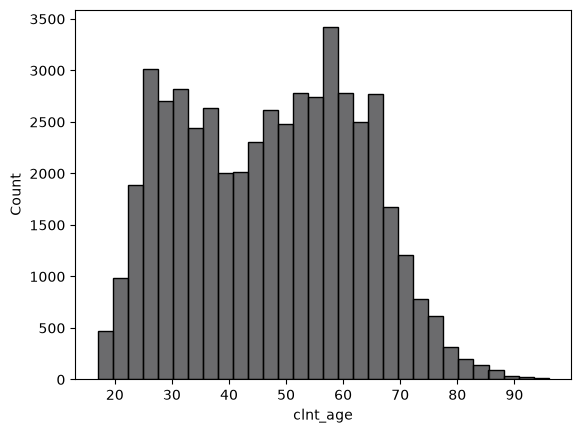

In [62]:
sns.histplot(df_clients["clnt_age"], bins=30, color=DARK_GRAY)

With naked eyes we can appreciate that most clients are around 55 years old.
More specifically, clients are generally middle-aged, with an average age of 46.4 years and a median of 47 years. The middle 50% of clients are between 32.5 and 59 years old.

### GENRE

<Axes: xlabel='gendr', ylabel='count'>

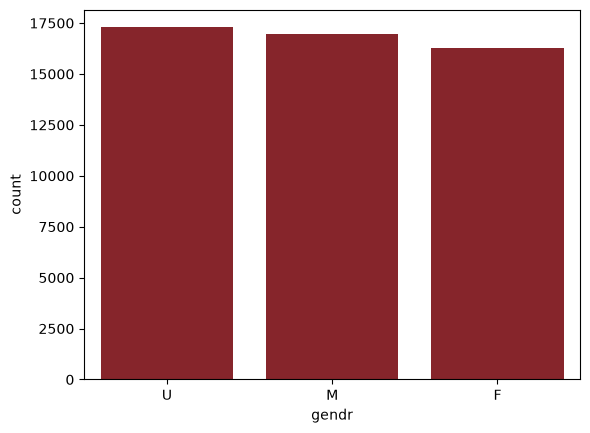

In [63]:
sns.countplot(data=df_clients, x="gendr", color=VANGUARD_RED)

The gender distribution is relatively balanced across the dataset. Clients classified as U represent the largest group (24,125), followed by M (23,724) and F (22,746). None of the categories dominates the client base, suggesting a fairly even distribution.
It is worth mentioning that there were 2 values as X. As we considered them unknown values we have merged them into the U column for a more concentrated classification.

### CLIENT TENURE

In [64]:
df_clients["clnt_tenure_yr"].describe()

count    50488.000000
mean        12.031730
std          6.860282
min          2.000000
25%          6.000000
50%         11.000000
75%         16.000000
max         55.000000
Name: clnt_tenure_yr, dtype: float64

<Axes: xlabel='clnt_tenure_yr', ylabel='Count'>

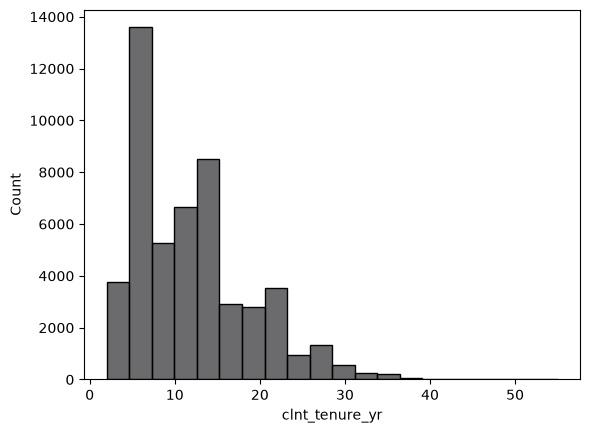

In [65]:
sns.histplot(df_clients["clnt_tenure_yr"], bins=20, color=DARK_GRAY)

The most common client tenure is around 7–8 years, although the median tenure is 11 years. This indicates that while the highest concentration of clients has been with Vanguard for around 7–8 years, half of the clients have been customers for at least 11 years. The distribution is right-skewed due to a smaller group of clients with much longer tenures. This is interesting because it shows that the group of clients that stays is actually small in contrast with the new acquisition groups. This could lead to a hypothesis that the company needs to work on a strategy to keep the clients longer term.

### NUMBER OF ACCOUNTS

In [66]:
df_clients["num_accts"].describe()

count    50488.000000
mean         2.254575
std          0.533671
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          7.000000
Name: num_accts, dtype: float64

<Axes: xlabel='num_accts', ylabel='Count'>

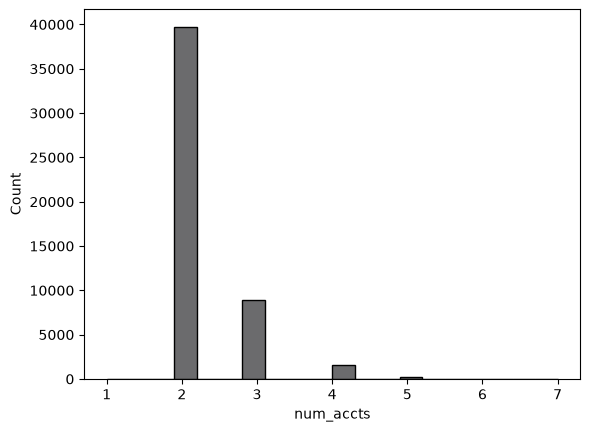

In [67]:
sns.histplot(df_clients["num_accts"], bins=20, color=DARK_GRAY)

There is a vast majority of clients having 2 accounts, > 50,000 clients, followed by clients with 3 accounts, slightly > 10,000.

### BALANCE

In [68]:
df_clients["bal"].describe().round(2)

count       50488.00
mean       149514.68
std        302036.42
min         23789.44
25%         39878.41
50%         65733.60
75%        139956.54
max      16320040.15
Name: bal, dtype: float64

<Axes: xlabel='bal', ylabel='Count'>

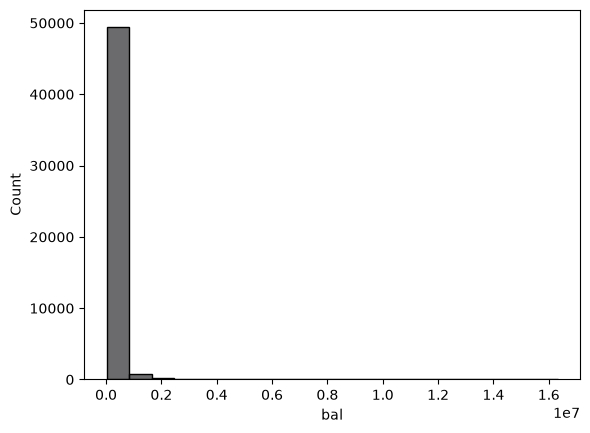

In [69]:
sns.histplot(df_clients["bal"], bins=20, color=DARK_GRAY)

<Axes: ylabel='bal'>

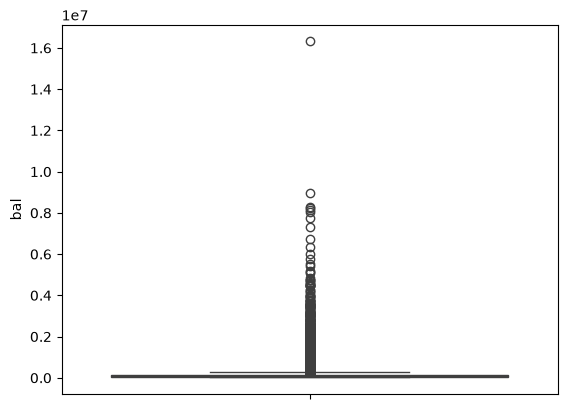

In [70]:
sns.boxplot(data = df_clients["bal"])

Account balances are highly dispersed. The mean ($147,445) is much higher than the median ($63,333), suggesting that a small number of high-balance clients skew the distribution to the right. The very large maximum balance confirms the presence of outliers.

### CALLS

In [71]:
df_clients["calls_6_mnth"].value_counts().sort_index()

calls_6_mnth
0.0     7732
1.0     7908
2.0     7215
3.0     5853
4.0     4848
5.0     4707
6.0    12225
Name: count, dtype: int64

<Axes: xlabel='calls_6_mnth', ylabel='count'>

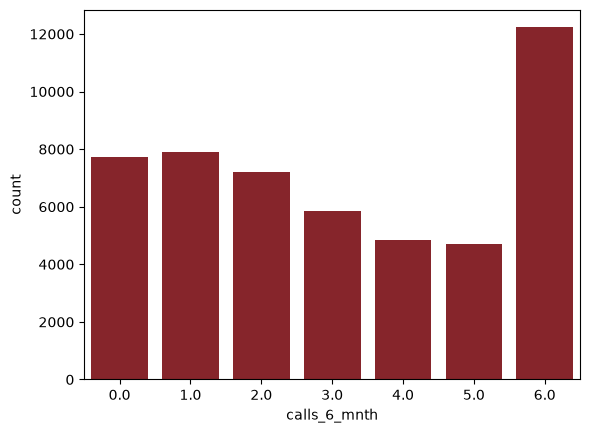

In [72]:
sns.countplot(data=df_clients, x="calls_6_mnth", color=VANGUARD_RED)

Most clients contacted customer service between 1 and 6 times during the last six months. The most common number of calls is 6, while relatively few clients made 7 calls.

### LOGONS

In [73]:
df_clients["logons_6_mnth"].describe()

count    50488.000000
mean         6.131873
std          2.175423
min          3.000000
25%          4.000000
50%          6.000000
75%          8.000000
max          9.000000
Name: logons_6_mnth, dtype: float64

<Axes: xlabel='logons_6_mnth', ylabel='Count'>

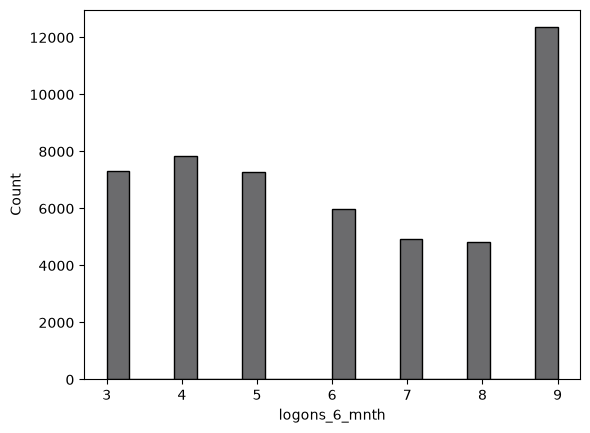

In [74]:
sns.histplot(df_clients["logons_6_mnth"], bins=20, color=DARK_GRAY)

In [75]:
df_clients["logons_6_mnth"].head()

0    9.0
1    9.0
2    9.0
3    6.0
4    3.0
Name: logons_6_mnth, dtype: float64

Client logins over the last six months range from 1 to 9. The most common value is 9 logins, suggesting that many clients accessed the platform frequently during the observed period. The absence of clients with 0 logins may indicate that the dataset only includes active users, although this cannot be confirmed without additional documentation. Without especulating, we can confirm that the highest of clients uses the app more frequently than the others.

### VARIATION

In [76]:
df_clients["variation"].value_counts(dropna=False)

variation
Test       26961
Control    23527
Name: count, dtype: int64

In [77]:
pd.crosstab(
    df_clients["variation"],
    df_clients["gendr"]
)

gendr,F,M,U
variation,,,
Control,7543,7970,8014
Test,8716,8977,9268


#### PRIMARY CLIENT PROFILE AND BEHAVIOUR

Overall, the typical Vanguard client is a middle-aged customer, maybe rather a male and very likely a new client in the company. Most clients have two accounts, use the platform more frequently, and show engagement through logins and customer service interactions with focus on 6 calls in the last 6 months. While most account balances are moderate, a small group of high-value clients significantly increases the average balance.

## DAY 3 (Week 5) - Performance Metrics

### KPIs:
1. Completion Rate: The proportion of users who reach the final 'confirm' step.

From df_final we need to split the clients who are part of Test group and those from Control group.

In [78]:
# First: only experiment clients (Test or Control)
df_final = df_final[df_final["variation"].notna()]

# Then split into two
df_test = df_final[df_final["variation"] == "Test"]
df_control = df_final[df_final["variation"] == "Control"]

In [79]:
df_test.head()

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,Test


In [80]:
df_control.head()

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
13,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:29:03,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0,Control
14,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:29:01,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0,Control
15,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05 12:28:52,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0,Control
16,4033851,762728880_76361333336,949661017_22392791362_127391,step_3,2017-04-05 12:26:08,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0,Control
17,4033851,762728880_76361333336,949661017_22392791362_127391,step_2,2017-04-05 12:24:43,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0,Control


Now we can check the completion rate for each one of them.

In [81]:
# Completion rate - Test
test_completion = (
    df_test[df_test["process_step"] == "confirm"]["client_id"].nunique()
    / df_test["client_id"].nunique()
)

# Completion rate - Control
control_completion = (
    df_control[df_control["process_step"] == "confirm"]["client_id"].nunique()
    / df_control["client_id"].nunique()
)

print(f"Test completion rate: {test_completion:.2%}")
print(f"Control completion rate: {control_completion:.2%}")

Test completion rate: 69.29%
Control completion rate: 65.58%


The difference between the two groups is not big, but we can see that the test group of clients has a higher %, 69.29%, compared to the control group, 65.58%.

2. Time Spent on Each Step: The average duration users spend on each step

In [82]:
df_control.info()

<class 'pandas.DataFrame'>
Index: 140494 entries, 13 to 317134
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   client_id         140494 non-null  int64  
 1   visitor_id        140494 non-null  str    
 2   visit_id          140494 non-null  str    
 3   process_step      140494 non-null  str    
 4   date_time         140494 non-null  str    
 5   clnt_tenure_yr    140494 non-null  float64
 6   clnt_tenure_mnth  140494 non-null  float64
 7   clnt_age          140482 non-null  float64
 8   gendr             140494 non-null  str    
 9   num_accts         140494 non-null  float64
 10  bal               140494 non-null  float64
 11  calls_6_mnth      140494 non-null  float64
 12  logons_6_mnth     140494 non-null  float64
 13  variation         140494 non-null  str    
dtypes: float64(7), int64(1), str(6)
memory usage: 27.1 MB


In [83]:
# Convert to datetime
df_test["date_time"] = pd.to_datetime(df_test["date_time"])
df_control["date_time"] = pd.to_datetime(df_control["date_time"])

# Sort events chronologically within each visit
df_test = df_test.sort_values(["client_id", "visit_id", "date_time"])
df_control = df_control.sort_values(["client_id", "visit_id", "date_time"])

# Time between consecutive events
df_test["time_diff"] = (
    df_test.groupby(["client_id", "visit_id"])["date_time"]
    .diff()
    .dt.total_seconds()
)

df_control["time_diff"] = (
    df_control.groupby(["client_id", "visit_id"])["date_time"]
    .diff()
    .dt.total_seconds()
)

# Assign the time to the PREVIOUS step
df_test["time_on_step"] = (
    df_test.groupby(["client_id", "visit_id"])["time_diff"]
    .shift(-1)
)

df_control["time_on_step"] = (
    df_control.groupby(["client_id", "visit_id"])["time_diff"]
    .shift(-1)
)

# Average time spent on each step
test_step_time = (
    df_test.groupby("process_step")["time_on_step"]
    .mean()
)

control_step_time = (
    df_control.groupby("process_step")["time_on_step"]
    .mean()
)

print("Test")
print(test_step_time)

print("\nControl")
print(control_step_time)

Test
process_step
confirm    243.690389
start       61.488630
step_1      60.675049
step_2      88.850910
step_3     129.649971
Name: time_on_step, dtype: float64

Control
process_step
confirm    168.760292
start       66.839095
step_1      50.477511
step_2      92.008064
step_3     137.130709
Name: time_on_step, dtype: float64


The redesigned interface appears to reduce the time users spend on most stages of the process, particularly at step_2 and step_3. However, users in the Test group spent slightly longer on step_1, suggesting that the initial interaction with the new interface may require additional time. Overall, the differences are relatively small, indicating that the redesign has only a modest impact on navigation speed.
As we know from our previous KPI, the completion rate is higher for the Test group than for the Control one.

3. Error Rates: If there's a step where users go back to a previous step, it may indicate confusion or an error. You should consider moving from a later step to an earlier one as an error.

In [84]:
# Define the correct step order
step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

# Convert process steps to numerical order
df_test["step_order"] = df_test["process_step"].map(step_order)
df_control["step_order"] = df_control["process_step"].map(step_order)

# Sort events chronologically
df_test = df_test.sort_values(["client_id", "visit_id", "date_time"])
df_control = df_control.sort_values(["client_id", "visit_id", "date_time"])

# Previous step within each visit
df_test["previous_step"] = (
    df_test.groupby(["client_id", "visit_id"])["step_order"]
    .shift(1)
)

df_control["previous_step"] = (
    df_control.groupby(["client_id", "visit_id"])["step_order"]
    .shift(1)
)

# Flag backward movements as errors
df_test["error"] = df_test["step_order"] < df_test["previous_step"]
df_control["error"] = df_control["step_order"] < df_control["previous_step"]

# Calculate error rate
test_error_rate = df_test["error"].mean()
control_error_rate = df_control["error"].mean()

print(f"Test error rate: {test_error_rate:.2%}")
print(f"Control error rate: {control_error_rate:.2%}")

Test error rate: 9.19%
Control error rate: 6.82%


Test group show a slightly higher error rate, 9.19%, compared to 6.82% for the control group. A lower error rate suggests users navigate the process more smoothly. A higher error rate may indicate confusion, unclear instructions, or usability issues that cause users to go back.

4. Drop-off Rate
Definition: The percentage of users who abandon the process before reaching the next step.

In [85]:
# Number of unique users reaching each step
test_steps = (
    df_test.groupby("process_step")["client_id"]
    .nunique()
    .reindex(["start", "step_1", "step_2", "step_3", "confirm"])
)

# Drop-off rate between consecutive steps
test_dropoff = (
    1 - test_steps.shift(-1) / test_steps
) * 100

print("Users reaching each step (Test)")
print(test_steps)

print("\nDrop-off rate (%)")
print(test_dropoff)

Users reaching each step (Test)
process_step
start      26672
step_1     24260
step_2     22252
step_3     20876
confirm    18682
Name: client_id, dtype: int64

Drop-off rate (%)
process_step
start       9.043191
step_1      8.276999
step_2      6.183714
step_3     10.509676
confirm          NaN
Name: client_id, dtype: float64


In [86]:
# Number of unique users reaching each step
control_steps = (
    df_control.groupby("process_step")["client_id"]
    .nunique()
    .reindex(["start", "step_1", "step_2", "step_3", "confirm"])
)

# Drop-off rate between consecutive steps
control_dropoff = (
    1 - control_steps.shift(-1) / control_steps
) * 100

print("Users reaching each step (Control)")
print(control_steps)

print("\nDrop-off rate (%)")
print(control_dropoff)

Users reaching each step (Control)
process_step
start      23392
step_1     20147
step_2     18645
step_3     17417
confirm    15429
Name: client_id, dtype: int64

Drop-off rate (%)
process_step
start      13.872264
step_1      7.455204
step_2      6.586216
step_3     11.414136
confirm          NaN
Name: client_id, dtype: float64


The Test group showed lower drop-off rates at most stages, especially at the start (9.04% vs. 13.87%), suggesting that the new interface improved user retention. The only exception was step_1, where the Test group had a slightly higher drop-off (8.28% vs. 7.46%).

### Based on the chosen KPIs, how does the new design's performance compare to the old one?

Overall, the new interface slightly outperformed the old one. Users in the Test group completed the process more often, experienced lower drop-off rates across most stages, and navigated several steps more efficiently. While the improvement is modest, the KPIs indicate that the redesign had a positive impact on the user experience.


## Day 4 & 5 (Week 5)

### Hypothesis Testing

1. Is the completion rate the same for clients in the Test group and clients in the Control group?

To evaluate whether the new website design improved user performance, we tested whether the completion rate differed between the Test and Control groups.

Since the objective was to determine whether the Test group achieved a higher completion rate than the Control group, we performed a one-tailed hypothesis test.

The hypothesis statement is:

In [87]:
# H0: Test completion rate <= Control completion rate
# H1: Test completion rate > Control completion rate

# significance level: 0.05

In [88]:
from statsmodels.stats.proportion import proportions_ztest

# Create a variable indicating whether each client completed the process
completion = (
    df_final
    .groupby(["client_id", "variation"])["process_step"]
    .apply(lambda x: (x == "confirm").any())
    .reset_index(name="completed")
)

# Number of clients who completed the process in each group
count = [
    completion.loc[completion["variation"] == "Test", "completed"].sum(),
    completion.loc[completion["variation"] == "Control", "completed"].sum()
]

# Total number of clients in each group
nobs = [
    completion.loc[completion["variation"] == "Test", "completed"].count(),
    completion.loc[completion["variation"] == "Control", "completed"].count()
]

# Two-proportion Z-test
z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="larger"
)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0: The Test group has a significantly higher completion rate.")
else:
    print("Fail to reject H0: There is insufficient evidence that the Test group has a higher completion rate.")

Z-statistic: 8.8894
P-value: 0.000000
Reject H0: The Test group has a significantly higher completion rate.


Since the p-value (0.0000) is lower than the significance level of 0.05, we reject the null hypothesis. There is statistically significant evidence that the Test group achieved a higher completion rate than the Control group. Therefore, we conclude that the new website design significantly improved the completion rate compared to the original design.

2. 5% Threshold Test - Completion rate

To determine whether the new website design is cost-effective, we tested whether the increase in the completion rate achieved by the Test group met Vanguard's minimum required improvement of 5 percentage points. Although the Test group showed a higher completion rate than the Control group, the company requires this increase to be at least 5 percentage points to justify the implementation costs.

Since the objective was to determine whether the observed increase reached or exceeded the 5% threshold, a one-tailed hypothesis test was performed.

The hypothesis statement is:

In [89]:
# H0: increase <= 5%
# H1: increase > 5%
# significance: 0.05

In [90]:
from scipy.stats import norm

# Completion rate per client (a client "completes" if they reach the confirm step)
n_test = df_test["client_id"].nunique()
n_control = df_control["client_id"].nunique()

p_test  = df_test.loc[df_test["process_step"] == "confirm", "client_id"].nunique() / n_test
p_control = df_control.loc[df_control["process_step"] == "confirm", "client_id"].nunique() / n_control

diff = p_test - p_control # observed increase
threshold = 0.05    # Vanguard's 5 percentage-point threshold

# One-sided z-test against a fixed value (0.05), so we use the unpooled standard error
se = np.sqrt(p_test*(1-p_test)/n_test + p_control*(1-p_control)/n_control)
z = (diff - threshold) / se
p_value = 1 - norm.cdf(z) # H1: increase > 0.05

print(f"Test completion rate: {p_test:.2%}")
print(f"Control completion rate: {p_control:.2%}")
print(f"Observed increase: {diff*100:.2f} percentage points")
print(f"Threshold: {threshold*100:.0f} percentage points")
print(f"z = {z:.2f}, p-value = {p_value:.3f}")
print("Result:", "Increase MEETS the 5pp threshold"
    if p_value < 0.05 else "Increase does NOT meet the 5pp threshold")

Test completion rate: 69.29%
Control completion rate: 65.58%
Observed increase: 3.71 percentage points
Threshold: 5 percentage points
z = -3.08, p-value = 0.999
Result: Increase does NOT meet the 5pp threshold


The Test group achieved a completion rate of 69.29%, compared to 65.58% for the Control group, resulting in an observed improvement of 3.71 percentage points. However, this increase is below Vanguard's required threshold of 5 percentage points.

Since the p-value (0.999) is greater than the significance level of 0.05, we fail to reject the null hypothesis. There is insufficient statistical evidence to conclude that the increase in completion rate meets or exceeds the 5 percentage point threshold. Therefore, although the new design improves the completion rate, the observed improvement is not large enough.

3. Is the average client tenure the same for clients in the Test group and clients in the Control group?

To verify whether the A/B test groups were comparable, we tested whether the average client tenure differed between the Test and Control groups.

This is a two-tailed test. The hypothesis statement is:

In [91]:
# H0: u_tenure_test = u_tenure_control
# H1: u_tenure_test != u_tenure_control

# significance level: 0.05

As we are comparing the mean for two different groups, we will conduct the two sample T-test.

In [92]:
df_control_tenure_avg = df_final[df_final["variation"] == "Control"]["clnt_tenure_yr"]
df_test_tenure_avg = df_final[df_final["variation"] == "Test"]["clnt_tenure_yr"]

In [93]:
import scipy.stats as st

st.ttest_ind(df_control_tenure_avg, df_test_tenure_avg)

TtestResult(statistic=np.float64(-0.5864156429169995), pvalue=np.float64(0.5575966520849713), df=np.float64(317133.0))

Since the p-value (0.5576) is greater than the significance level of 0.05, we fail to reject the null hypothesis. There is no statistically significant evidence that the average client tenure differs between the Test and Control groups. We can conclude that the average client tenure is similar across both groups.

### Experiment Evaluation



In order to carry out the evaluation of the experiment, we wanted to check how the groups were divided between them.

In [94]:
print(df_final["variation"].value_counts())  # counts ROWS (web events)
print(df_final.groupby("variation")["client_id"].nunique()) # counts unique CLIENTS

variation
Test       176641
Control    140494
Name: count, dtype: int64
variation
Control    23527
Test       26961
Name: client_id, dtype: int64


In [95]:
diff = 26961 - 23527
print("The difference between the two groups is:", diff)

The difference between the two groups is: 3434


In [96]:
sum = 26961 + 23527
print("The total amount of clients in the experiment is:", sum)

The total amount of clients in the experiment is: 50488


In [97]:
print("The difference in % between the two groups is: ",  round((3434 / 50488) * 100, 2), "%")

The difference in % between the two groups is:  6.8 %


Having this percentage, 6.8%, we carried out a Hypothesis test to understand whether this was statistically significant.

In [98]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# Observed data
test = 26961
control = 23527
total = test + control

# H0: 50% of users should be assigned to Test
count = test          # successes (users in Test)
nobs = total          # total users

# Two-sided one-sample proportion test
z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    value=0.50,
    alternative='two-sided'
)

print(f"Observed proportion (Test): {test/total:.4f}")
print(f"Expected proportion: 0.5000")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# Interpretation
alpha = 0.05

if p_value < alpha:
    print("\nReject H0")
    print("The allocation differs significantly from a 50/50 split.")
else:
    print("\nFail to reject H0")
    print("The observed difference is consistent with random assignment.")

Observed proportion (Test): 0.5340
Expected proportion: 0.5000
Z-statistic: 15.3184
P-value: 5.7628e-53

Reject H0
The allocation differs significantly from a 50/50 split.


A one-sample proportion test was conducted to determine whether users were equally assigned between the Control and Test groups. Under the null hypothesis of a 50/50 allocation, the observed Test proportion was 53.4% (26,961 of 50,488 users). The test yielded p<0.001, indicating that the observed allocation differs significantly from an equal split. Therefore, the imbalance is unlikely to be explained by random variation alone. This suggests that the experiment may have used an unequal traffic allocation or that the assignment process should be reviewed.

##### Evaluation of the experiment:

General information:

Experiment period: 15 March 2017 – 20 June 2017 (approximately 97 days)

Control group: 23,526 clients

Test group: 26,961 clients

Difference: 3,435 clients

Total participants: 50,487 clients

Split: 53.4% Test / 46.6% Control (a ~6.8% imbalance toward the Test group)


Note: group sizes are counted as unique clients (client_id.nunique()), not web-event rows. The raw web data has ~317,000 event rows because each client generates several rows (one per process step), so counting rows would overstate the group sizes.
1. Design Effectiveness

Was the experiment well-structured? 

Overall yes. It follows a standard A/B design with two variations (Control and Test), changing only one main element (the UI), which is the right way to isolate the impact of the redesign.

Were clients randomly and equally divided? 

Not perfectly. The split is 53.4% Test / 46.6% Control rather than a clean 50/50. This imbalance is modest and does not invalidate the experiment — many real A/B tests use unequal allocation on purpose (to expose more users to a promising feature or reduce risk). Importantly, our own randomisation checks show the groups are demographically comparable: the two-sample t-test on client tenure found no significant difference (p = 0.56), and age/balance are also well matched. So even with unequal sizes, random assignment appears to have been preserved.

Were there any biases? 

A few to acknowledge: the unequal group sizes slightly affect statistical power; the ~3-month window could introduce time-based effects (weekends, holidays, seasonal behaviour, marketing campaigns); and without randomisation logs we can't fully rule out selection bias. Although there is no direct evidence that these factors affected the experiment, they should be acknowledged as potential limitations.

2. Duration Assessment

The experiment ran ~97 days, which is more than enough for an A/B test of this kind. 

Advantages: a large sample (50,487 clients), coverage of both weekday and weekend behaviour, reduced impact of short-term noise, and high statistical reliability. Risks of such a long window: seasonal effects, drift in customer behaviour over time, and concurrent marketing or website changes unrelated to the redesign. Assuming the site stayed relatively stable, the duration was adequate for meaningful conclusions.

3. Additional Data Needs

The analysis could be strengthened with: 
- the cost of the redesign (needed to properly judge the 5% cost-effectiveness threshold instead of assuming it);
- client satisfaction / feedback (to explain the higher error/back-navigation rate in the Test group); 
- device type (desktop / mobile / tablet); 
- traffic source; 
- the reason ~20,000 clients were left unassigned (to confirm dropping them doesn't bias results); 
- exact assignment dates and randomisation logs (to verify fair, evenly-distributed assignment); 
- and longer-term outcomes like retention (completion at one point in time doesn't capture lasting impact).


### Overall Evaluation

The experiment is reasonably well-designed, with a large sample and sufficient duration for reliable analysis. The main thing to verify is the unequal allocation (53.4% Test vs 46.6% Control) — whether it was intentional or a randomisation artefact. Since our balance checks show the groups are demographically comparable, the experiment can still support valid conclusions: the redesign produced a statistically significant lift in completion (69.29% vs 65.58%), though that lift falls short of Vanguard's 5-percentage-point cost-effectiveness threshold.

### Visualization

We have created a visualization in form of barchart for our first hypothesis in Python.

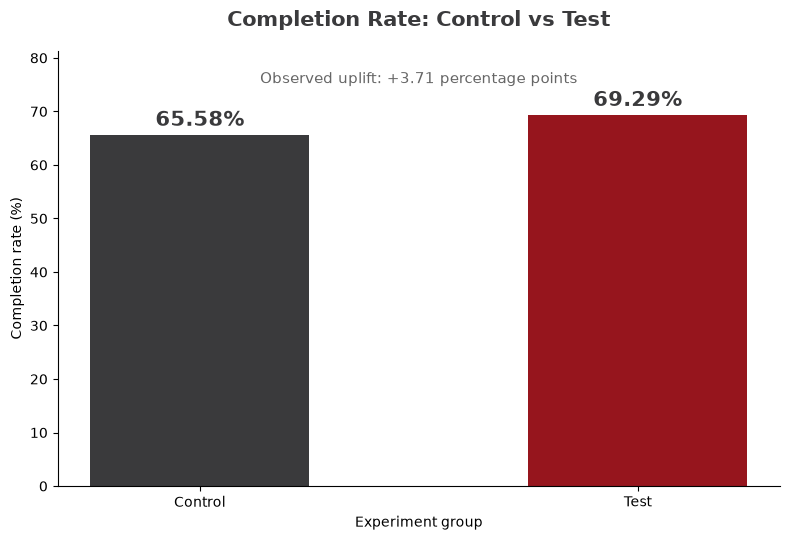

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

VANGUARD_RED = "#96151D"
DARK_GRAY    = "#3A3A3C"
brand_colors = [DARK_GRAY, VANGUARD_RED]

df = pd.read_csv("df_final.csv", low_memory=False)

client_completion = (
    df.groupby(["client_id", "variation"])["process_step"]
      .apply(lambda steps: int("confirm" in steps.values))
      .reset_index(name="completed")
)

completion_rates = (
    client_completion.groupby("variation")["completed"]
    .mean().mul(100).reindex(["Control", "Test"])
)
uplift = completion_rates["Test"] - completion_rates["Control"]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(completion_rates.index, completion_rates.values,
              color=brand_colors, width=0.5)

for bar, rate in zip(bars, completion_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{rate:.2f}%", ha="center", va="bottom",
            fontsize=15, fontweight="bold", color=DARK_GRAY)

ax.text(0.5, max(completion_rates.values) + 6,
        f"Observed uplift: +{uplift:.2f} percentage points",
        ha="center", fontsize=11, color="#666666")

ax.set_title("Completion Rate: Control vs Test",
             fontsize=15, fontweight="bold", color=DARK_GRAY, pad=18)
ax.set_xlabel("Experiment group")
ax.set_ylabel("Completion rate (%)")
ax.set_ylim(0, max(completion_rates.values) + 12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("completion_rate.png", dpi=200, bbox_inches="tight")
plt.show()

Now we are visualizing the Error Rate metric for the user interface improvement.

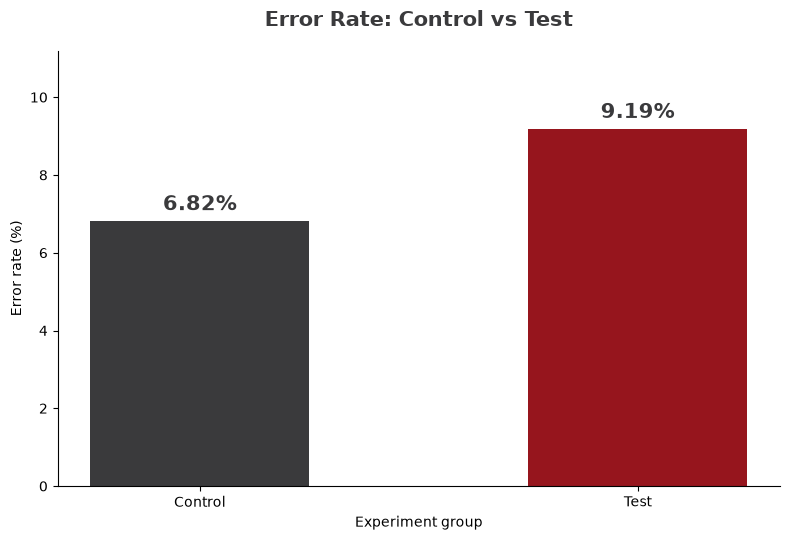

In [100]:
groups = ["Control", "Test"]
error_rates = [control_error_rate * 100, test_error_rate * 100]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(groups, error_rates, color=brand_colors, width=0.5)

for bar, rate in zip(bars, error_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f"{rate:.2f}%", ha="center", va="bottom",
            fontsize=15, fontweight="bold", color=DARK_GRAY)

ax.set_title("Error Rate: Control vs Test",
             fontsize=15, fontweight="bold", color=DARK_GRAY, pad=18)
ax.set_xlabel("Experiment group")
ax.set_ylabel("Error rate (%)")
ax.set_ylim(0, max(error_rates) + 2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("error_rate.png", dpi=200, bbox_inches="tight")
plt.show()

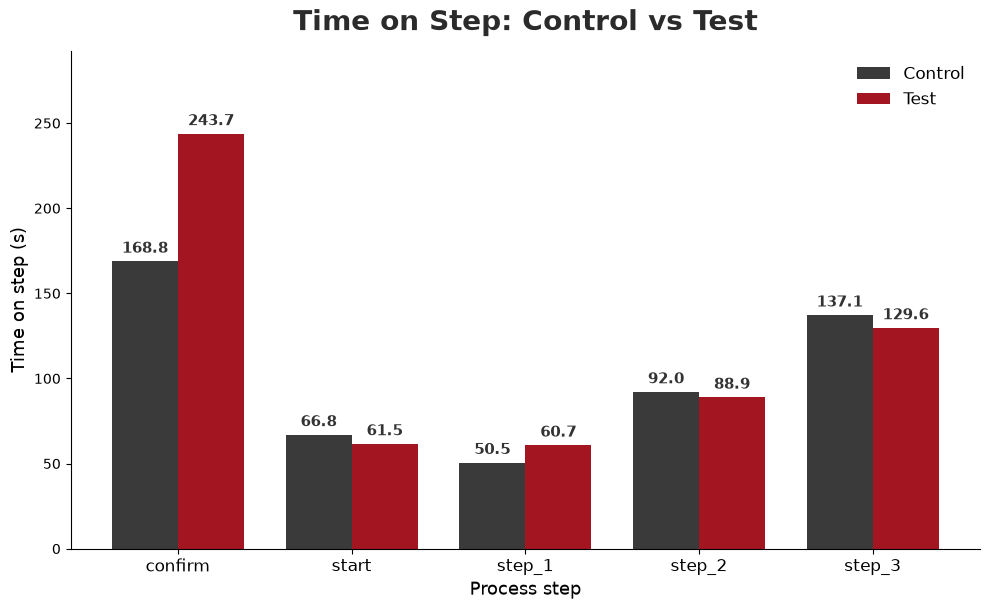

In [101]:
import matplotlib.pyplot as plt
import numpy as np

steps = ["confirm", "start", "step_1", "step_2", "step_3"]
test_vals = [243.690389, 61.488630, 60.675049, 88.850910, 129.649971]
control_vals = [168.760292, 66.839095, 50.477511, 92.008064, 137.130709]

# Same palette as other charts: dark gray for Control, dark red for Test
color_control = "#3A3A3A"
color_test = "#A31621"

x = np.arange(len(steps))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 6.2))

bars_control = ax.bar(x - width/2, control_vals, width, label="Control", color=color_control)
bars_test = ax.bar(x + width/2, test_vals, width, label="Test", color=color_test)

# Fixed indentation in the loop
for bars in (bars_control, bars_test):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 3, f"{h:.1f}",
                ha="center", va="bottom", fontsize=11, fontweight="bold", color="#333333")

ax.set_title("Time on Step: Control vs Test", fontsize=20, fontweight="bold", color="#2B2B2B", pad=15)
ax.set_xlabel("Process step", fontsize=13)
ax.set_ylabel("Time on step (s)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(steps, fontsize=12)
ax.legend(frameon=False, fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(max(test_vals), max(control_vals)) * 1.2)

plt.tight_layout()
plt.savefig("time_on_step.png", dpi=200)
plt.show()

For future research, it would be interesting to explore the type of errors that the users get. For the interface improvement. This would be helpful for the Frontend team.

Now, the rest of the visualization will be shown in Tableau.